# Predicting Rocket Launch Delays
## Notebook 01 · Launch-delay detectives

**Dr. Mohammed Hussin Talafha**  
Postdoctoral Research Fellow · University of Sharjah  
**الدكتور محمد حسين طلافحة — التنبؤ بتأخيرات إطلاق الصواريخ**

Rocket Revolution · World Space Week 2026 · SSAH  
**7 October 2026 · 11:00–12:00 UAE time (UTC+4) · 60 minutes**

Start here. Run a cell, change an input, and explain what happened.
Work alone or with a partner; no previous machine-learning experience is needed.

> **Your mission:** one hour before a fictional launch, predict whether it will be
> more than 15 minutes late or scrubbed. All records are **simulated**; scores describe
> this simulation, not real launch reliability or launch clearance.

<img src="../assets/images/artemis-i-launch.jpg" alt="Artemis I lifting off at night from Kennedy Space Center" width="800">

*Artemis I, 16 November 2022. Credit: NASA/Joel Kowsky. [Image source](https://www.nasa.gov/image-article/artemis-i-launch-2/).*


### Your plan for the next hour

You will read a data table, draw charts, spot information from the future, and train
a decision tree to predict a delay flag.

| Minutes | Activity | Your task |
|---|---|---|
| 00–05 | Meet the challenge | Predict a fictional launch outcome |
| 05–12 | First Python cells | Change a value and rerun |
| 12–22 | Inspect the records | Find missing values and unsuitable inputs |
| 22–32 | Explore with charts | Compare patterns and sample sizes |
| 32–42 | Build a baseline | Explain the three data splits |
| 42–55 | Train a decision tree | Compare shallow and deeper trees |
| 55–60 | Predict a new attempt | Write your conclusion |

### 00–05 · Meet the challenge

Imagine two attempts: one with low wind and no open technical items, another with
strong wind and two open technical items. **Which seems more likely to be delayed?**
Make your guess before running the code.

Our target is `delayed = 1` for a delay **greater than 15 minutes**, or a **scrub**
(cancellation of this attempt). Otherwise it is `0`. Exactly 15 minutes is class `0`.
We predict a yes/no outcome at **T−60 minutes**, not the exact delay duration.

**Discuss:** can a sensible prediction still be wrong? What information might be missing?


### 05–12 · Run your first cells

1. In Codespaces, wait for setup to finish and select **Python (Rocket Workshop)**.
2. Click a code cell and press **Shift+Enter**. Work from top to bottom.
3. Read the output below the cell. At **YOUR TURN**, edit the suggested value and rerun.

Text cells explain the activity; code cells calculate. Comments beginning with `#`
explain each code line. Every code cell has a working starting example.

If something fails, see [Need help?](../README.md#need-help). For a fresh start,
restart the kernel and run the earlier cells again in order.


In [1]:
from pathlib import Path  # Import Path to find folders and files on this computer.
import sys  # Import sys to report which Python version is running.
import numpy as np  # Import NumPy as np for numerical arrays and calculations.
import pandas as pd  # Import pandas as pd for reading and analysing data tables.
import matplotlib.pyplot as plt  # Import Matplotlib's plotting tools using the short name plt.
import sklearn  # Import scikit-learn so we can report its installed version.
from IPython.display import display  # Import display to show formatted tables inside the notebook.

SEED = 2026  # Choose a fixed random seed so repeated model fits are reproducible.
plt.rcParams.update({  # Start setting default styles for the figures created below.
    "figure.figsize": (9, 4.5), "figure.dpi": 110,  # Set default figure size in inches and resolution in dots per inch.
    "axes.spines.top": False, "axes.spines.right": False,  # Hide the top and right borders around each plot.
    "axes.titlesize": 14, "axes.labelsize": 11,  # Set font sizes for plot titles and axis labels.
    "font.size": 10, "axes.titlepad": 12,  # Set the general font size and spacing above plot titles.
    "axes.prop_cycle": plt.cycler(color=["#146C94", "#E08028", "#428C72"]),  # Choose three colours that plots will cycle through.
})  # Finish the style dictionary and apply these plotting defaults.
print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | scikit-learn {sklearn.__version__}")  # Print library versions; [0] keeps just the Python version number.
print("Ready. Run the next cell.")  # Print a confirmation that the imports and plotting setup finished.

Python 3.12.14 | pandas 2.2.3 | scikit-learn 1.8.0
Ready. Run the next cell.


In [2]:
# YOUR TURN 1: change 42 to 10, then run again. The 35 km/h cut is an invented example.
wind_speed = 42  # Store a sample wind speed of 42 kilometres per hour; try changing it.
example_flag = wind_speed > 35  # Check whether the wind exceeds the invented example cut of 35 km/h.
print(f"Wind: {wind_speed} km/h | example flag: {example_flag}")  # Print the wind value and the resulting True or False flag.
print("This number is invented; it is not a real launch limit.")  # Print the limitation of this invented cut.

Wind: 42 km/h | example flag: True
This number is invented; it is not a real launch limit.


`=` stores a value; `>` asks a question; `True` and `False` are the possible answers.
Later, a decision tree will learn its rules from examples.

**Checkpoint:** change the wind value so the flag switches between `True` and `False`.

### 12–22 · Meet the data

One row is one **fictional mission's first attempt**. The 960 rows have unique mission
IDs. Weather columns contain forecasts available at T−60 for the planned launch window.

We split the records now and explore **training rows only**. Validation is the practice
exam; the test set is the final exam in Notebook 02.


In [3]:
# Find the repository whether the kernel starts in its root or notebooks/.
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]  # Search the current directory, then its parents, for the repository.
             if (p / "data/synthetic_launch_attempts.csv").is_file()), None)  # Take the first folder containing the CSV; use None if none is found.
if ROOT is None:  # Check whether the search failed to find our bundled data file.
    raise FileNotFoundError("Open this notebook inside the workshop repository; data/synthetic_launch_attempts.csv is required.")  # Stop with a clear instruction if the notebook is outside the repository.

data = pd.read_csv(ROOT / "data/synthetic_launch_attempts.csv", parse_dates=[  # Read the CSV table and start listing columns to parse as timestamps.
    "scheduled_launch_utc", "prediction_time_utc", "outcome_recorded_utc"  # Name the schedule, prediction and outcome-recording timestamp columns.
]).sort_values("scheduled_launch_utc").reset_index(drop=True)  # Sort attempts by scheduled time and replace the row index with 0, 1, 2, ...
assert len(data) == 960 and data["mission_id"].is_unique  # Check that there are 960 rows and every mission ID occurs only once.
assert set(data["delayed"]) == {0, 1}  # Check that the target contains exactly the two classes 0 and 1.
assert data["scheduled_launch_utc"].is_monotonic_increasing  # Check that scheduled launch times are in chronological order.
assert ((data["scheduled_launch_utc"] - data["prediction_time_utc"]) == pd.Timedelta(hours=1)).all()  # Check that every prediction time is exactly one hour before its schedule.
expected_label = (data["scrubbed"].eq(1) | data["actual_delay_minutes"].gt(15)).astype(int)  # Build 0/1 labels: a scrub OR a delay greater than 15 minutes gives 1.
assert data["delayed"].equals(expected_label)  # Check that the stored target matches the label definition for every row.

# Use earlier attempts for training and later attempts for evaluation.
train = data.iloc[:576].copy()  # Copy the first 576 rows for training; iloc's upper limit is excluded.
valid = data.iloc[576:768].copy()  # Copy rows at positions 576 through 767 for validation.
test = data.iloc[768:].copy()  # Copy positions 768 onward for the final test in notebook 02.
assert train["outcome_recorded_utc"].max() < valid["prediction_time_utc"].min()  # Ensure all training outcomes are known before validation predictions begin.
assert valid["outcome_recorded_utc"].max() < test["prediction_time_utc"].min()  # Ensure all validation outcomes are known before test predictions begin.
assert set(train.mission_id).isdisjoint(valid.mission_id)  # Check that training and validation have no mission IDs in common.
assert set(train.mission_id).isdisjoint(test.mission_id)  # Check that training and testing have no mission IDs in common.
assert set(valid.mission_id).isdisjoint(test.mission_id)  # Check that validation and testing have no mission IDs in common.
print(f"{len(data)} fictional attempts | train {len(train)} | validation {len(valid)} | test {len(test)}")  # Print the total number of attempts and the size of each split.

960 fictional attempts | train 576 | validation 192 | test 192


In [4]:
preview_columns = ["mission_id", "forecast_wind_kmh", "forecast_rain_pct",  # Start a list of columns to display, including mission ID, wind and rain.
                   "forecast_lightning_pct", "open_technical_items", "delayed"]  # Complete the list with lightning, technical items and the outcome.
display(train[preview_columns].head(8))  # Show the first eight training rows for the selected columns.
print("Training outcome counts:")  # Print a heading for the table of training outcomes.
display(train["delayed"].value_counts().sort_index().rename(index={0: "Within 15 min", 1: "Delayed / scrubbed"}).to_frame("attempts"))  # Count each class, order 0 before 1, add readable labels and show a table.
print("Missing values in the four first-model inputs:")  # Print a heading for the missing-input summary.
display(train[preview_columns[1:-1]].isna().sum().to_frame("missing"))  # Select only the four inputs, count missing entries per column and display.

,mission_id,forecast_wind_kmh,forecast_rain_pct,forecast_lightning_pct,open_technical_items,delayed
0,SIM-0001,10.9,23.0,15.9,0,0
1,SIM-0002,24.3,21.9,16.9,1,0
2,SIM-0003,39.1,15.7,10.2,0,1
3,SIM-0004,NaN,5.7,18.4,1,0
4,SIM-0005,30.9,23.8,0.0,0,0
5,SIM-0006,28.8,52.2,14.6,0,0
6,SIM-0007,38.2,23.0,0.0,2,0
7,SIM-0008,37.2,13.0,44.7,0,0


Training outcome counts:


,attempts
delayed,
Within 15 min,318
Delayed / scrubbed,258


Missing values in the four first-model inputs:


,missing
forecast_wind_kmh,19
forecast_rain_pct,24
forecast_lightning_pct,25
open_technical_items,0


| Column | Meaning | Use as an input? |
|---|---|---|
| `forecast_wind_kmh` | Forecast wind speed, km/h | Yes |
| `forecast_rain_pct` | Forecast chance of rain, 0–100% | Yes |
| `forecast_lightning_pct` | Forecast chance of lightning, 0–100% | Yes |
| `open_technical_items` | Unresolved checklist items at T−60 | Yes |
| `actual_delay_minutes` | Delay measured after the attempt | **No: future information** |
| `scrubbed` | Whether the attempt was eventually cancelled | **No: future information** |
| `delayed` | The outcome to predict | Target only |

Missing weather means **unknown**, not zero. We will fill it using training medians.
See the [full data dictionary](../data/README.md) for other columns.

**YOUR TURN 2:** why would using `actual_delay_minutes` as an input be cheating?
Does a blank delay mean the attempt went well?

<details>
<summary>Hint</summary>

Actual delay is known after the event and reveals the target. A scrub has no liftoff
time for this attempt, so its delay in minutes is blank, but its target is 1.

</details>


### 22–32 · Explore with charts

Look for patterns in the **training set**. A pattern is an association, not proof
of a cause. The simulated weather forecasts are related to each other.


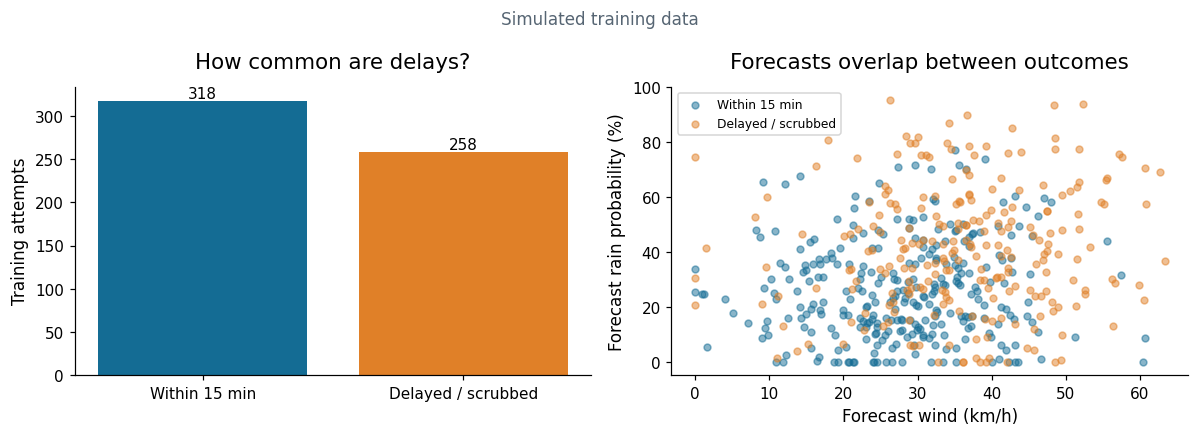

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))  # Create one figure with two side-by-side plotting areas, 11 by 4 inches.
counts = train["delayed"].value_counts().reindex([0, 1], fill_value=0)  # Count training labels in order 0, 1; use zero if a class is absent.
axes[0].bar(["Within 15 min", "Delayed / scrubbed"], counts, color=["#146C94", "#E08028"])  # Draw one bar per outcome, using blue for class 0 and orange for class 1.
axes[0].set(ylabel="Training attempts", title="How common are delays?")  # Label the first plot's vertical axis and give it a title.
for x, n in enumerate(counts):  # Loop over each bar position x and its count n.
    axes[0].text(x, n + 3, str(n), ha="center")  # Write each count just above its bar, horizontally centred.
for label, colour, text in [(0, "#146C94", "Within 15 min"), (1, "#E08028", "Delayed / scrubbed")]:  # Loop through each class with its chosen colour and legend description.
    rows = train.loc[train.delayed == label]  # Select training rows belonging to the current outcome class.
    axes[1].scatter(rows.forecast_wind_kmh, rows.forecast_rain_pct, s=20, alpha=0.5, color=colour, label=text)  # Plot wind against rain; use small, partly transparent points for overlap.
axes[1].set(xlabel="Forecast wind (km/h)", ylabel="Forecast rain probability (%)", title="Forecasts overlap between outcomes")  # Label the scatter plot's axes with units and add its title.
axes[1].legend(fontsize=8)  # Show the colour key on the scatter plot in a smaller font.
fig.suptitle("Simulated training data", fontsize=11, color="#566573")  # Add a figure-wide heading identifying these records as simulated.
fig.tight_layout()  # Adjust spacing so plot labels and titles fit without overlapping.
plt.show()  # Display the completed figure in the notebook.

In [6]:
# YOUR TURN 3: try 25, 35 and 45. Check both the rate AND the group size.
wind_cut = 35  # Choose the wind cut in km/h; try 25, 35 or 45 for this exercise.
wind_rows = train.dropna(subset=["forecast_wind_kmh"]).copy()  # Copy training rows with known wind; this omission is only for this comparison.
wind_rows["wind_group"] = np.where(wind_rows.forecast_wind_kmh > wind_cut,  # Check which retained rows have wind above the chosen cut.
                                   f"Above {wind_cut} km/h", f"At/below {wind_cut} km/h")  # Assign one of two readable group names according to that condition.
wind_summary = wind_rows.groupby("wind_group")["delayed"].agg(attempts="size", delay_rate="mean")  # For each group, count attempts and average the 0/1 delay label.
wind_summary["delay_rate_pct"] = 100 * wind_summary.pop("delay_rate")  # Convert the mean label to a percentage and remove the old fraction column.
display(wind_summary.round(1))  # Display group counts and percentages rounded to one decimal place.
print(f"Omitted {train.forecast_wind_kmh.isna().sum()} training rows with unknown wind for this chart only.")  # Report how many training rows were omitted because their wind was unknown.

,attempts,delay_rate_pct
wind_group,,
Above 35 km/h,224,61.6
At/below 35 km/h,333,33.9


Omitted 19 training rows with unknown wind for this chart only.


**Write an observation:** “Above ___ km/h, ___% of training attempts were delayed
or scrubbed, based on ___ examples.” Why is the group size useful?
The wind cut is for comparison; it is not a physical launch limit.

### 32–42 · Build a baseline

| Split | Rows | Purpose |
|---|---|---|
| Training | First 576 | Learn missing-value replacements and model rules |
| Validation | Next 192 | Compare model settings |
| Test | Last 192 | Evaluate the fixed choice in Notebook 02 |

Time order lets us learn from earlier attempts and predict later ones. Each mission
appears once. With real data, keep rescheduled attempts together and use only outcomes
already known at training time.

- **Baseline:** always predict the most common training class.
- **Accuracy:** the fraction of all predictions that are correct.
- **Delay recall:** the fraction of actual delays that are caught.

A **pipeline** performs steps in order: fill missing values, then make a prediction.
`fit` learns from training rows; `predict` applies those learned steps to new rows.


In [7]:
from sklearn.pipeline import Pipeline  # Import Pipeline to combine data preparation and a model in one workflow.
from sklearn.impute import SimpleImputer  # Import SimpleImputer to replace missing input values.
from sklearn.dummy import DummyClassifier  # Import a simple classifier to provide a reference baseline.
from sklearn.tree import DecisionTreeClassifier, plot_tree  # Import the decision-tree model and the function that draws its structure.
from sklearn.metrics import accuracy_score, recall_score  # Import measures of overall correctness and the fraction of delays caught.

FEATURES = ["forecast_wind_kmh", "forecast_rain_pct",  # Start the list of model inputs with wind and rain forecasts.
            "forecast_lightning_pct", "open_technical_items"]  # Complete the input list with lightning forecasts and technical item counts.
assert not set(FEATURES) & {"delayed", "actual_delay_minutes", "scrubbed", "outcome_recorded_utc"}  # Check that no target or post-event information appears in the input list.
X_train, y_train = train[FEATURES], train["delayed"]  # Separate training inputs X_train from training outcomes y_train.
X_valid, y_valid = valid[FEATURES], valid["delayed"]  # Separate validation inputs X_valid from validation outcomes y_valid.

baseline = Pipeline([  # Start a pipeline whose steps will run in the listed order.
    ("fill_missing", SimpleImputer(strategy="median")),  # Set missing numeric values to be filled with medians learned during fit.
    ("model", DummyClassifier(strategy="most_frequent")),  # Choose a baseline that always predicts the most common training class.
])  # Finish defining the two-step baseline pipeline.
baseline.fit(X_train, y_train)  # Learn the medians and the majority class using training data only.
baseline_prediction = baseline.predict(X_valid)  # Apply the fitted baseline to validation inputs to get predicted classes.
print(f"Baseline validation accuracy: {accuracy_score(y_valid, baseline_prediction):.1%}")  # Print the fraction of correct validation predictions as a percentage.
print(f"Baseline validation delay recall: {recall_score(y_valid, baseline_prediction, zero_division=0):.1%}")  # Print the fraction of actual delays caught; return 0 if the metric is undefined.

Baseline validation accuracy: 56.2%
Baseline validation delay recall: 0.0%


**Checkpoint:** how could a model have useful-looking accuracy but miss every delay?

### 42–55 · Train a decision tree

A tree asks a sequence of questions. Its final group, called a **leaf**, uses the
training outcomes in that group to estimate the class.

`max_depth=3` allows at most three questions per path. `min_samples_leaf=20` requires
at least 20 training rows in each leaf. Run the next two cells and follow one path
through the tree diagram.


In [8]:
tree = Pipeline([  # Start a pipeline for preparing inputs and training a decision tree.
    ("fill_missing", SimpleImputer(strategy="median")),  # Fill missing inputs with medians learned from the training data.
    ("model", DecisionTreeClassifier(max_depth=3, min_samples_leaf=20, random_state=SEED)),  # Allow three questions per path, at least 20 rows per leaf, and a fixed seed.
])  # Finish defining the tree pipeline.
tree.fit(X_train, y_train)  # Learn input medians and tree rules from the training examples.
tree_prediction = tree.predict(X_valid)  # Use the learned tree to predict classes for the validation attempts.
comparison = pd.DataFrame([  # Start a table comparing the baseline and tree on the same validation set.
    {"model": "Majority baseline", "accuracy": accuracy_score(y_valid, baseline_prediction),  # Store the baseline name and its overall fraction of correct predictions.
     "delay_recall": recall_score(y_valid, baseline_prediction, zero_division=0)},  # Store the baseline's fraction of actual delays caught; finish this row.
    {"model": "Decision tree", "accuracy": accuracy_score(y_valid, tree_prediction),  # Store the tree name and its overall fraction of correct predictions.
     "delay_recall": recall_score(y_valid, tree_prediction, zero_division=0)},  # Store the tree's fraction of actual delays caught; finish this row.
]).set_index("model")  # Build the table and use model names as row labels.
display(comparison.round(3))  # Display the comparison rounded to three decimal places.

,accuracy,delay_recall
model,,
Majority baseline,0.562,0.00
Decision tree,0.641,0.56


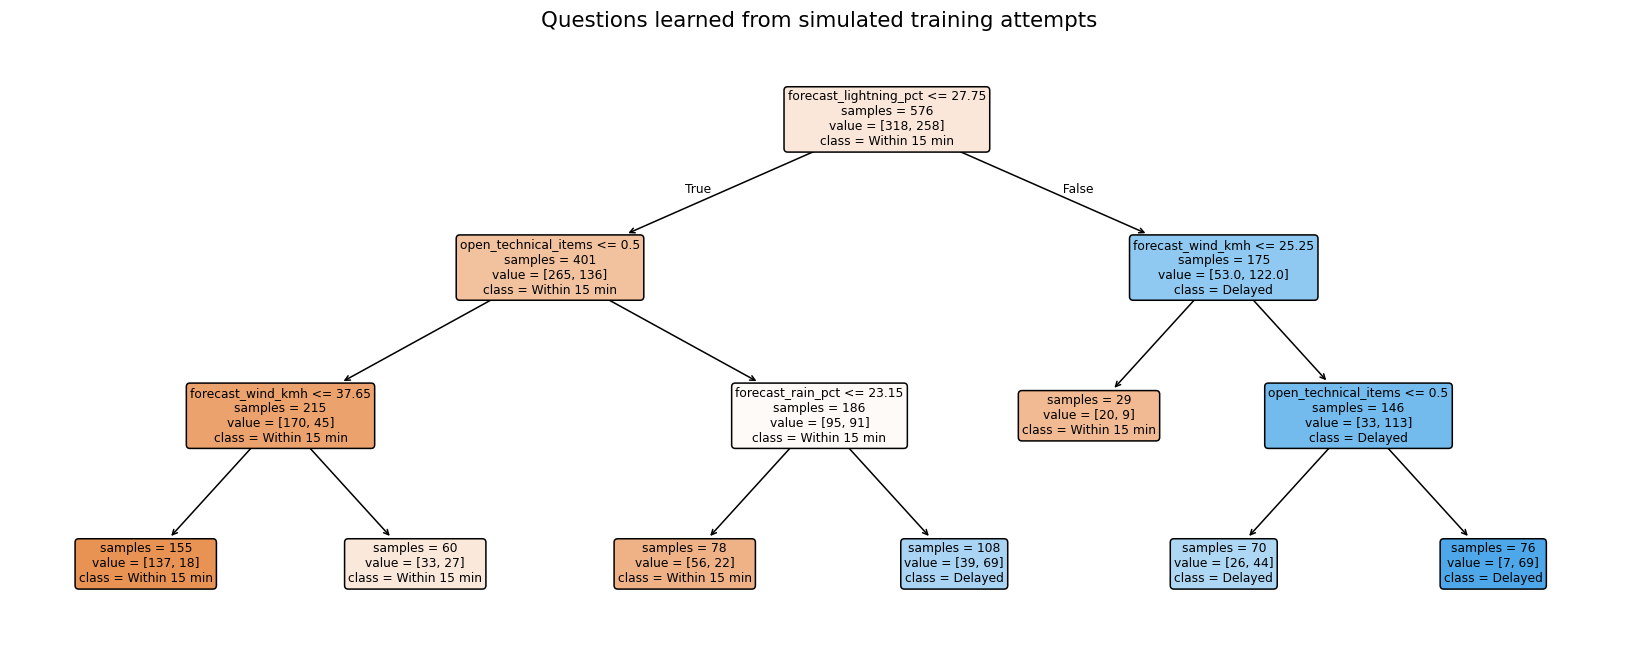

In [9]:
fig, ax = plt.subplots(figsize=(15, 6))  # Create a wide plotting area so the decision tree is easier to read.
plot_tree(tree.named_steps["model"], feature_names=FEATURES,  # Draw the fitted model inside the pipeline and label splits with input names.
          class_names=["Within 15 min", "Delayed"], filled=True,  # Label classes 0 and 1 and colour nodes according to their class composition.
          impurity=False, rounded=True, fontsize=8, ax=ax)  # Hide impurity scores and use rounded boxes and small text on this plot.
ax.set_title("Questions learned from simulated training attempts")  # Give the diagram a title that identifies the data as simulated.
plt.tight_layout()  # Adjust the figure layout to accommodate its labels.
plt.show()  # Show the decision-tree diagram.

**Read the tree:** go left when the condition is true and right when it is false.
`samples` counts rows reaching a node; `value` counts the two classes; `class` shows
the majority class. The split values were learned from the simulated examples.


In [10]:
# YOUR TURN 4: try 1, 3 and 8. Compare training AND validation accuracy.
trial_depth = 8  # Choose a trial maximum depth; try 1, 3 and 8 while keeping other settings fixed.
trial_tree = Pipeline([  # Start a separate pipeline so the original tree remains available.
    ("fill_missing", SimpleImputer(strategy="median")),  # Fill unknown input values using training medians.
    ("model", DecisionTreeClassifier(max_depth=trial_depth, min_samples_leaf=5, random_state=SEED)),  # Build a trial tree with the chosen depth, at least five rows per leaf and a seed.
])  # Finish defining this experimental pipeline.
trial_tree.fit(X_train, y_train)  # Fit the trial pipeline using the same training inputs and outcomes.
display(pd.DataFrame({  # Start a small table comparing performance on familiar and unseen examples.
    "split": ["Training", "Validation"],  # Name the two rows Training and Validation.
    "accuracy": [trial_tree.score(X_train, y_train), trial_tree.score(X_valid, y_valid)],  # Calculate classification accuracy on the training and validation splits.
}).round(3))  # Round the table to three decimal places and display it.
print("The next prediction uses the original depth-3 tree.")  # Print which model is used for the next prediction.

,split,accuracy
0,Training,0.854
1,Validation,0.620


The next prediction uses the original depth-3 tree.


**YOUR TURN 4 — reflect:** did a deeper tree improve validation as much as training?
Learning overly specific rules is called **overfitting**.

<details>
<summary>Hint</summary>

A larger training–validation gap suggests overfitting. Compare settings on validation;
keep the final test set for the finished choice.

</details>

### 55–60 · Predict a new attempt

Change one input at a time and compare the estimate with your first guess. The value
is the model's estimate from simulated examples, not a verified real-world probability.


In [11]:
# YOUR TURN 5: change one input at a time, keeping values within the training ranges.
new_attempt = pd.DataFrame([{  # Start a one-row table describing a new fictional launch attempt.
    "forecast_wind_kmh": 40.0,  # Set its forecast wind speed to 40 km/h.
    "forecast_rain_pct": 55.0,  # Set its forecast chance of rain to 55 percent.
    "forecast_lightning_pct": 35.0,  # Set its forecast chance of lightning to 35 percent.
    "open_technical_items": 2,  # Set the number of unresolved technical items to two.
}])[FEATURES]  # Finish the table and order its input columns to match training.
delay_probability = tree.predict_proba(new_attempt)[0, 1]  # Select row 0, class 1 from the predicted class-probability table.
print(f"Simulated delay probability estimate: {delay_probability:.1%}")  # Show the simulated delay estimate as a percentage with one decimal place.
print("Class at threshold 0.50:", "Delay flag" if delay_probability >= 0.5 else "No delay flag")  # Print a delay flag when that estimate is at least 0.50.
print("A lower estimate does not guarantee an on-time launch.")  # Print the uncertainty that remains after a prediction.

Simulated delay probability estimate: 90.8%
Class at threshold 0.50: Delay flag
A lower estimate does not guarantee an on-time launch.


### Exit ticket

Double-click this text cell, replace the answers, and press **Shift+Enter**.

1. One useful input available at T−60: **your answer**.
2. One input to exclude, and why: **your answer**.
3. Compared with the baseline, my tree: **your answer with a validation metric**.

**Next:** open [Notebook 02 — From predictions to decisions](02_launch_delay_decisions.ipynb).
You will combine trees, compare mistakes, and choose an alert threshold.

**Optional extra:** replace one forecast input with `np.nan` and predict again.
Which training statistic fills it? Why would using the test median be unfair?


### Explore further

- [Data dictionary](../data/README.md) — column meanings, units, and how the simulated records were created.
- [NASA: Artemis I weather criteria](https://www.nasa.gov/directorates/esdmd/common-exploration-systems-development-division/orion-program/artemis-i-weather-criteria/) — real launch context; the workshop's numeric rules are invented.
- [scikit-learn: avoiding data leakage](https://scikit-learn.org/stable/common_pitfalls.html).
- [Image sources and credits](../assets/IMAGE_CREDITS.md).

**Dr. Mohammed Hussin Talafha · University of Sharjah**
